## Normalizng Flows

#### The core idea behind normalising flows is deceptively simple: if we can express a complex distribution as an invertible transformation of a tractable one, then both Sampling and density evaluation reduce to applications of the change-of-variables formula. From  a base distribution $u\sim\mathcal{N}(o,\mathbf{I})$, and appying a diffemorphism $T$, the densoity of $\theta = T(\mathbf{u})$ is 
$$
  p_{\theta}(\theta) = p_{\mathbf{u}}\!\left(T^{-1}(\theta)\right) 
    \left|\det J_{T^{-1}}(\theta)\right|,
$$
#### A single transformation rarely suffices, but diffeomorphisms compose:  stacking $K$: layers as $T = T_K \circ \cdots \circ T_1$ yields
$$
   \log p_{\theta}(\theta) = \log p_{\mathbf{u}}(\mathbf{u}) 
    - \sum_{k=1}^{K} \log\left|\det J_{T_k}(\mathbf{z}_{k-1})\right|,
$$
#### where each added layer increases the family of representable distributions. For NPE, we need more than an unconditional density---we need $q_{\bm{\phi}}(\theta \mid \mathbf{y})$, a posterior that adapts to each observation. The solution is to condition the transformation itself on $y$:
$$
    q_{\bm{\phi}}(\theta \mid y) = p_{\mathbf{u}}\!\left(T^{-1}(\theta; y)\right) 
    \left|\det J_{T^{-1}}(\theta; y)\right|.
$$
#### Now different observations induce different posteriors through the same network weights. The computational obstacle in the above equation is the Jacobian determinant: a naïve implementation costs $\mathcal{O}(d^3)$ per layer, which becomes prohibitive even for modest parameter dimensions. The solution adopted by all modern flow architectures is to constrain the Jacobian to be triangular, so  that its determinant reduces to the product of diagonal entries, $\mathcal{O}(d)$ operations regardless of network depth.

#### **RealNVP** stands for Real-valued Non-Volume Preserving transformations. It is one of the foundational architectures for Normalising Flows. "2D" simply means we are operating on two-dimensional data.

In [9]:
import torch 
import torch.nn as nn
import torch.distributions as dist
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import torch.optim as optim
import numpy as np

In [7]:
class AffineCouplingLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim, mask):
        super().__init__()
        # The mask tells us which dimensions to keep unchanged (True) 
        # and which to transform (False)
        self.mask = mask 
        
        # This network predicts how to scale (s) and translate (t) the data.
        # Notice it outputs input_dim * 2 because we need both s and t!
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim * 2) 
        )

    def forward(self, x):
        """ Data Space -> Latent Space (Used for Density Evaluation) """
        # 1. Apply mask to get the unchanged part of the data
        x_masked = x * self.mask
        
        # 2. Predict scale (s) and translation (t)
        s_and_t = self.net(x_masked)
        s, t = s_and_t.chunk(2, dim=1)
        
        # 3. Ensure we only apply s and t to the dimensions we are transforming
        s = s * (~self.mask)
        t = t * (~self.mask)
        
        # 4. The Inverse Transformation: T^{-1}(x) -> u
        u = (x - t) * torch.exp(-s)
        
        # 5. The Log-Determinant of the Jacobian
        log_det_J = -s.sum(dim=1) 
        
        return u, log_det_J

    def inverse(self, u):
        """ Latent Space -> Data Space (Used for Sampling) """
        u_masked = u * self.mask
        s_and_t = self.net(u_masked)
        s, t = s_and_t.chunk(2, dim=1)
        
        s = s * (~self.mask)
        t = t * (~self.mask)
        
        # The Forward Transformation: T(u) -> x
        x = u * torch.exp(s) + t
        return x

## Composing the Flow
#### A single coupling layer isn't very powerful because it leaves half the data completely untouched! As discussed in the text, diffeomorphisms compose. We can stack K layers, alternating our mask each time so that all dimensions get transformed.
$$
\log p_{\theta} (\theta) = \log p_u - \sum_{k=1}^K \log |\rm{det}   J_T|
$$

In [8]:
class ToyNormalizingFlow(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, n_layers=4):
        super().__init__()
        
        # The base distribution p_u(u) = N(0, I)
        self.base_dist = dist.MultivariateNormal(
            torch.zeros(input_dim), 
            torch.eye(input_dim)
        )
        
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            # Alternate the mask [True, False] -> [False, True] layer by layer
            mask = torch.tensor([i % 2 == 0, i % 2 == 1])
            self.layers.append(AffineCouplingLayer(input_dim, hidden_dim, mask))

    def log_prob(self, x):
        """ Calculates the exact density of the data: p(x) """
        log_det_jacobian_sum = torch.zeros(x.shape[0])
        u = x
        
        # Push data backwards through the flow to the base distribution
        for layer in self.layers:
            u, log_det_J = layer(u)
            log_det_jacobian_sum += log_det_J
            
        # Change of variables formula
        log_p_u = self.base_dist.log_prob(u)
        return log_p_u + log_det_jacobian_sum

    def sample(self, num_samples):
        """ Generates new data by sampling from the base distribution """
        # Draw from N(0, I)
        u = self.base_dist.sample((num_samples,))
        x = u
        
        # Push forward through the flow to data space
        # Note: We reverse the layer order when going from Latent -> Data
        for layer in reversed(self.layers):
            x = layer.inverse(x)
            
        return x

## The Dataset and The Objective
#### To train our Normalising Flow, we need a complex distribution to learn. We will use the "Two Moons" dataset from Scikit-Learn.
#### Our goal is Maximum Likelihood Estimation (MLE). We want to find the neural network weights $\theta$ that maximize the probability of our data x. In practice, we do this by minimizing the Negative Log-Likelihood (NLL):
$$

\mathcal{L} = - \frac{1}{N} \sum_{i=1}^N        \log p_{\theta}(x_i),
$$ 
#### here $\log p_{\theta}(x_i)$ is exactly what our log_prob function computes!

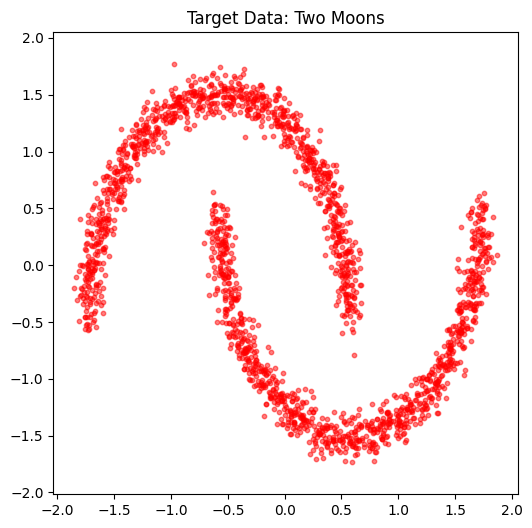

In [10]:
# 1. Generate the Two Moons dataset
n_samples = 2000
data, _ = make_moons(n_samples=n_samples, noise=0.05, random_state=42)

# Standardize the data (Flows learn much better when data is centered around 0)
data = (data - data.mean(axis=0)) / data.std(axis=0)

# Convert to PyTorch tensor
x_train = torch.tensor(data, dtype=torch.float32)

# Plot the target distribution
plt.figure(figsize=(6, 6))
plt.scatter(x_train[:, 0], x_train[:, 1], alpha=0.5, s=10, color='red')
plt.title("Target Data: Two Moons")
plt.axis('equal')
plt.show()

## The Training Loop

In [11]:
# Initialize the flow
# 8 layers gives it enough flexibility to learn the curves
flow = ToyNormalizingFlow(input_dim=2, hidden_dim=64, n_layers=8)

# Standard Adam optimizer
optimizer = optim.Adam(flow.parameters(), lr=1e-3)

epochs = 1000
batch_size = 500

print("Starting training...")
for epoch in range(epochs):
    # Randomly shuffle the data
    permutation = torch.randperm(x_train.size()[0])
    
    epoch_loss = 0.0
    for i in range(0, x_train.size()[0], batch_size):
        optimizer.zero_grad()
        
        # Get a batch
        indices = permutation[i:i+batch_size]
        batch_x = x_train[indices]
        
        # Compute the exact log-probability of the data: log p(x)
        log_prob = flow.log_prob(batch_x)
        
        # Loss is the Negative Log-Likelihood
        loss = -log_prob.mean() 
        
        # Backpropagate and update weights
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss / (n_samples // batch_size):.4f}")

print("Training complete!")

Starting training...
Epoch 200/1000 | Loss: 1.5574
Epoch 400/1000 | Loss: 1.2022
Epoch 600/1000 | Loss: 1.1570
Epoch 800/1000 | Loss: 1.1595
Epoch 1000/1000 | Loss: 1.1391
Training complete!
